# HAC  

**Approach**: Pure HAC — natural k determined from dendrogram (min_k=5, max_k=20)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import math
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize, Normalizer, FunctionTransformer
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud
from collections import Counter
from matplotlib import cm
import warnings
import os
import random
import services.utils as ut
import services.model as md_module

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
np.random.seed(42)
random.seed(42)
print('Libraries loaded.')
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import umap as umap_lib


/opt/anaconda3/envs/research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


## 1. Load Data

In [2]:
data_df = ut.load_data('customer_support_tickets.csv')
data_df = data_df.drop_duplicates(subset=['Ticket Description'], keep='first').reset_index(drop=True)
data_df['text'] = data_df['Ticket Description'].fillna('')
if data_df is not None:
    print('Data loaded successfully')
print(data_df.head())

Data loaded successfully
   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   

## 2. Preprocessing

In [3]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)
    return text

data_df['clean_text'] = data_df['text'].apply(clean_text)
data_df['clean_text'].head()

0     having  issue with the  please assist\n\nyour...
1     having  issue with the  please assist\n\n you...
2     facing  problem with   the   not turning   wa...
3     having  issue with the  please assist\n\n you...
4     having  issue with the  please assist\n\n\nno...
Name: clean_text, dtype: object

In [4]:
custom_words = {
    'please', 'help', 'assist', 'support', 'thanks', 'thank', 'soon', 'mentioned',
    'im', 'ive', 'us', 'would', 'could', 'need', 'want', 'trying',
    'tried', 'check', 'checked', 'make', 'made', 'get', 'getting', 'also',
    'use', 'using', 'used', 'thing', 'something', 'anything', 'everything',
    'way', 'time', 'issue', 'problem', 'request',
    'work', 'working', 'fine', 'available', 'recent', 'recently', 'facing', 'doe',
    'noticed', 'happening', 'started', 'happen', 'different', 'steps', 'did',
    'regards', 'already', 'multiple', 'last', 'times', 'followed', 'reviewed',
    'specific', 'possible', 'related', 'new', 'old', 'find', 'try', 'trying', 'say', 'mean',
    'name', 'email', 'price', 'one', 'add', 'note', 'may', 'dont', 'know', 'sure',
    'changes', 'performed', 'properly', 'original', 'like', 'similar', 'reported', 'doesnt',
    'sometimes', 'acts', 'works', 'ensure', 'desired', 'action', 'remains', 'life', 'seems',
    'might', 'guide', 'much', 'others', 'heavily', 'daily', 'task',
    'affecting', 'assistance', 'hoping', 'persists', 'didnt',
    'option', 'perform', 'recommendation', 'information', 'official',
    'solution', 'provide', 'making', 'user', 'customer', 'item', 'device',
    'far', 'luck', 'contact', 'contacted', 'occurring'
}
custom_words_lemma = set([lemmatizer.lemmatize(w) for w in custom_words])

def preprocess(text):
    tokens = word_tokenize(text)
    processed_tokens = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word)
        if lemma not in stop_words and lemma not in custom_words_lemma and len(lemma) > 2:
            processed_tokens.append(lemma)
    return ' '.join(processed_tokens)

data_df['processed_text'] = data_df['clean_text'].apply(preprocess)

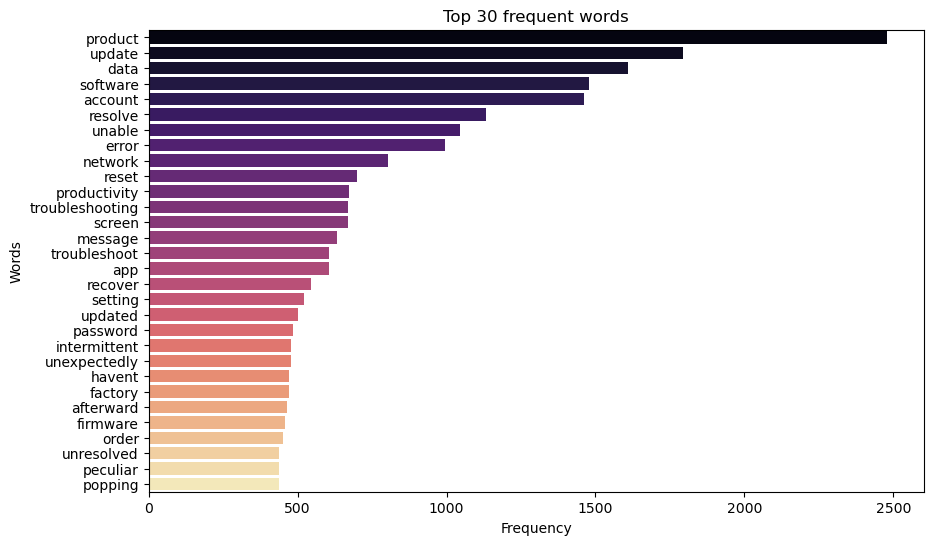

In [5]:
text_data = data_df['processed_text'].astype(str)
all_words = ' '.join(text_data).lower().split()
common_words = Counter(all_words).most_common(30)
words, counts = zip(*common_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title('Top 30 frequent words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

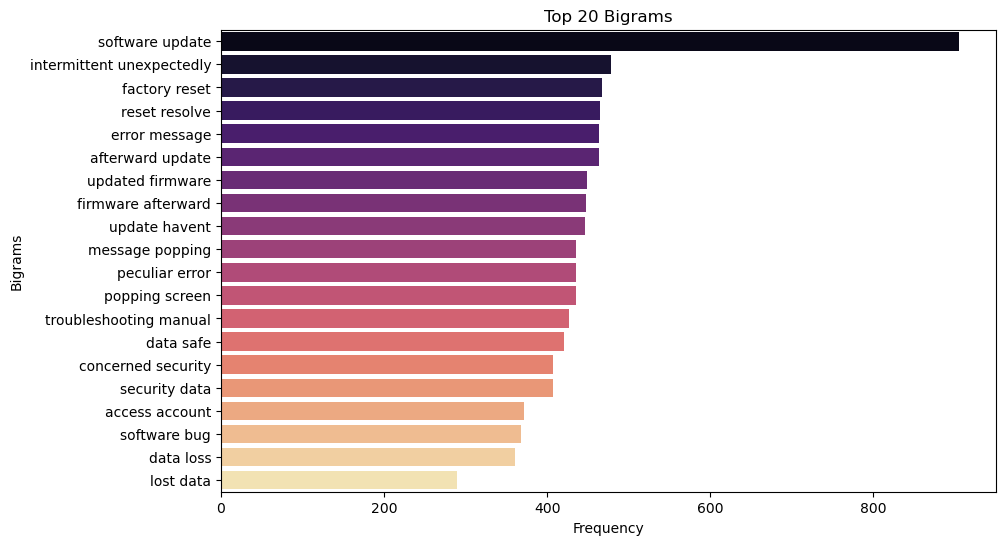

In [6]:
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
x = vectorizer.fit_transform(data_df['processed_text'])
word_counts = x.sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq = list(zip(words, word_counts))
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:20]
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma')
plt.title('Top 20 Bigrams')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

In [7]:
ut.save_data(data_df, 'cleaned_data.csv')

## 3. Text Representation

### 3.1 TF-IDF

In [8]:
def nlp_cleaner(text_list):
    results = []
    for text in text_list:
        cleaned = clean_text(text)
        processed = preprocess(cleaned)
        results.append(processed)
    return results

In [9]:
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.7)
X = tfidf.fit_transform(data_df['processed_text'])

In [10]:
tfidf__preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner, validate=False)),
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5, max_df=0.7))
])

### 3.2 Sentence Embeddings

In [11]:
def clean_for_embeddings(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r"i'?m having an issue with.*?please assist\.?", ' ', text)
    text = re.sub(r'please assist\.?', ' ', text)
    text = re.sub(r'\b(id|created_at|product|price)\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [12]:
data_df['embedding_text'] = data_df['text'].apply(clean_for_embeddings)

In [13]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21111.92it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
embeddings = model.encode(data_df['embedding_text'].tolist(), show_progress_bar=True)

Batches: 100%|██████████| 253/253 [00:09<00:00, 26.31it/s]


In [15]:
embeddings = normalize(embeddings)

In [16]:
print(cosine_similarity([embeddings[0]], [embeddings[1]]))
print(cosine_similarity([embeddings[2]], [embeddings[5]]))

[[0.33734772]]
[[0.6662934]]


In [17]:
def nlp_cleaner_embeddings(text_list):
    results = []
    for text in text_list:
        cleaned = clean_for_embeddings(text)
        results.append(cleaned)
    return results

In [18]:
embedding_preprocessing_pipeline = Pipeline([
    ('cleaner', FunctionTransformer(nlp_cleaner_embeddings, validate=False)),
    ('embeddings', md_module.SentenceEmbeddingTransformer(model_name='all-MiniLM-L6-v2')),
    ('normalize', Normalizer())
])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9138.50it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 4. HAC Clustering



### 4.0 Baseline: HAC on Raw Features (No Dimensionality Reduction)


Computing baseline HAC linkage matrices (no dim reduction)...
Done.

Baseline HAC Silhouette Scores:
  k=5 | TF-IDF  sil=0.0470       | Embed   sil=0.0789
  k=6 | TF-IDF  sil=0.0559       | Embed   sil=0.0760
  k=7 | TF-IDF  sil=0.0599       | Embed   sil=0.0803
  k=8 | TF-IDF  sil=0.0649       | Embed   sil=0.0913
  k=9 | TF-IDF  sil=0.0723       | Embed   sil=0.0986
  k=10 | TF-IDF  sil=0.0773       | Embed   sil=0.1047


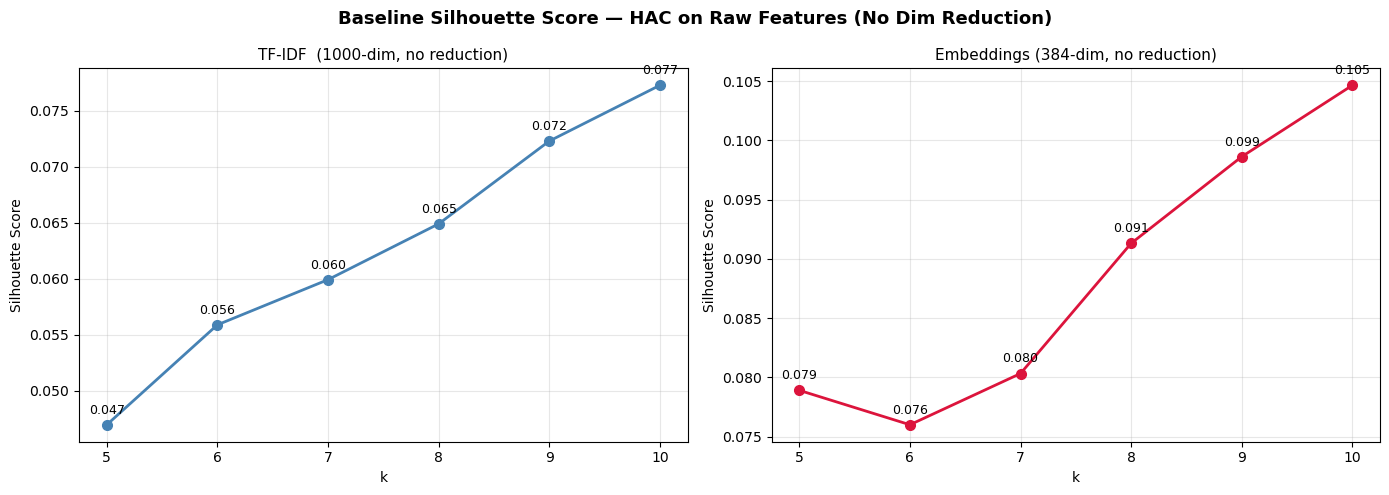

In [19]:
from scipy.cluster.hierarchy import linkage as _linkage, fcluster as _fcluster

# Raw feature matrices (no dim reduction)
X_tfidf_raw = normalize(X).toarray()   # 1000-dim TF-IDF
X_embed_raw = embeddings               # 384-dim embeddings (already normalised)

print('Computing baseline HAC linkage matrices (no dim reduction)...')
Z_tfidf_raw = _linkage(X_tfidf_raw, method='ward')
Z_embed_raw = _linkage(X_embed_raw, method='ward')
print('Done.')

# Sweep k=5..10 and record silhouette scores
K_RANGE_BASE = range(5, 11)
sil_base_tfidf, sil_base_embed = [], []

print('\nBaseline HAC Silhouette Scores:')
for k in K_RANGE_BASE:
    lbl_t = _fcluster(Z_tfidf_raw, t=k, criterion='maxclust') - 1
    lbl_e = _fcluster(Z_embed_raw, t=k, criterion='maxclust') - 1
    sil_t = silhouette_score(X_tfidf_raw, lbl_t)
    sil_e = silhouette_score(X_embed_raw, lbl_e)
    sil_base_tfidf.append(sil_t)
    sil_base_embed.append(sil_e)
    print(f'  k={k} | TF-IDF  sil={sil_t:.4f}       | Embed   sil={sil_e:.4f}')

k_list_base = list(K_RANGE_BASE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline Silhouette Score — HAC on Raw Features (No Dim Reduction)',
             fontsize=13, fontweight='bold')
for ax, sil, name, color in [
    (axes[0], sil_base_tfidf, 'TF-IDF  (1000-dim, no reduction)', 'steelblue'),
    (axes[1], sil_base_embed, 'Embeddings (384-dim, no reduction)', 'crimson'),
]:
    ax.plot(k_list_base, sil, 'o-', color=color, linewidth=2, markersize=7)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
    for k, s in zip(k_list_base, sil):
        ax.annotate(f'{s:.3f}', (k, s), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 4.1 Dimensionality Reduction

In [ ]:
# PCA-100 for TF-IDF 
X_tfidf_norm = normalize(X)
from sklearn.decomposition import PCA
pca100 = PCA(n_components=100, random_state=42)
X_tfidf_pca = pca100.fit_transform(X_tfidf_norm.toarray())
pca2d = PCA(n_components=2, random_state=42)
X_tfidf_2d = pca2d.fit_transform(X_tfidf_norm.toarray())
print(f'TF-IDF PCA-100 variance explained: {pca100.explained_variance_ratio_.sum()*100:.1f}%')

# UMAP-20 for Embeddings (clustering)
reducer20 = umap_lib.UMAP(n_components=20, n_neighbors=30, min_dist=0.0,
                           metric='cosine', random_state=42)
X_embed_umap = normalize(reducer20.fit_transform(embeddings))

# UMAP-2D for visualisation
reducer2d = umap_lib.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                           metric='cosine', random_state=42)
X_embed_2d = reducer2d.fit_transform(embeddings)
print(f'UMAP-20: {X_embed_umap.shape} | UMAP-2D: {X_embed_2d.shape}')

TF-IDF PCA-100 variance explained: 64.6%


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP-20: (8077, 20) | UMAP-2D: (8077, 2)


### 4.2 Build Linkage Matrices

In [21]:
print('Computing linkage for TF-IDF + PCA...')
Z_tfidf = linkage(X_tfidf_pca, method='ward')
print('Computing linkage for Embeddings + UMAP...')
Z_embed = linkage(X_embed_umap, method='ward')
print('Done.')

Computing linkage for TF-IDF + PCA...
Computing linkage for Embeddings + UMAP...
Done.


### 4.3 Dendrogram — Finding the Natural Cut



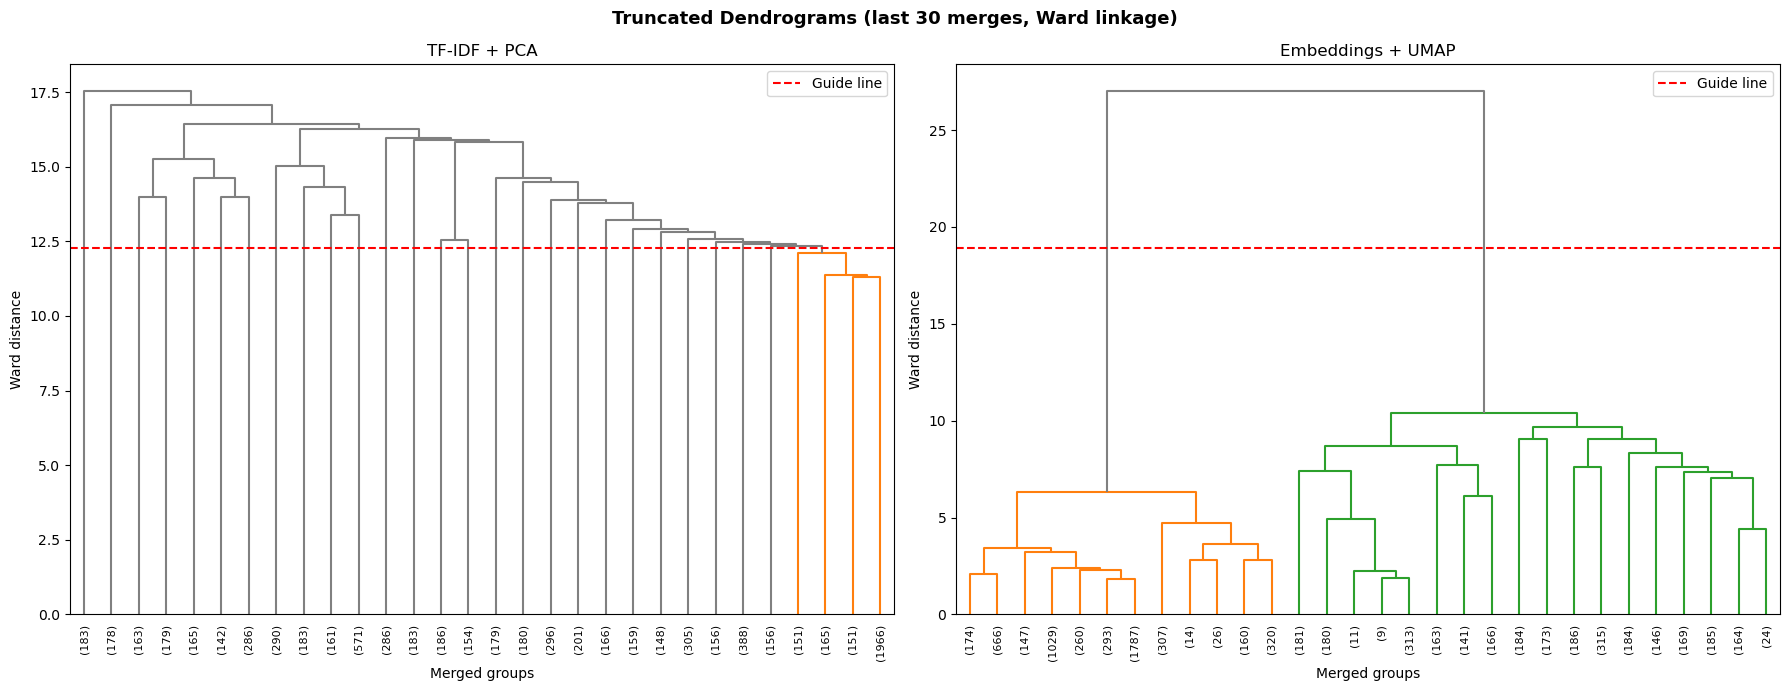

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Truncated Dendrograms (last 30 merges, Ward linkage)', fontsize=13, fontweight='bold')
for ax, Z, name in [
    (axes[0], Z_tfidf, 'TF-IDF + PCA'),
    (axes[1], Z_embed, 'Embeddings + UMAP'),
]:
    ct = 0.7 * max(Z[:, 2])
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8,
               color_threshold=ct, above_threshold_color='grey', ax=ax)
    ax.axhline(ct, color='red', linestyle='--', linewidth=1.5, label=f'Guide line')
    ax.set_title(name); ax.set_xlabel('Merged groups'); ax.set_ylabel('Ward distance')
    ax.legend()
plt.tight_layout(); plt.show()

### 4.4 Automatic Cut 

In [23]:
def find_best_cut(Z, min_k=5, max_k=20):
    n = len(Z) + 1
    ks = list(range(min_k, max_k + 1))
    dists = np.array([Z[n - 1 - k, 2] for k in ks])
    gaps = dists[:-1] - dists[1:]
    best_idx = np.argmax(gaps)
    best_k = ks[best_idx]
    threshold = (dists[best_idx] + dists[best_idx + 1]) / 2
    return threshold, best_k, ks, dists, gaps

thresh_tfidf, k_tfidf, ks_t, dists_t, gaps_t = find_best_cut(Z_tfidf)
thresh_embed, k_embed, ks_e, dists_e, gaps_e = find_best_cut(Z_embed)
print(f'TF-IDF     → natural k={k_tfidf},  threshold={thresh_tfidf:.4f}')
print(f'Embeddings → natural k={k_embed},  threshold={thresh_embed:.4f}')

TF-IDF     → natural k=7,  threshold=15.5453
Embeddings → natural k=15,  threshold=5.5232


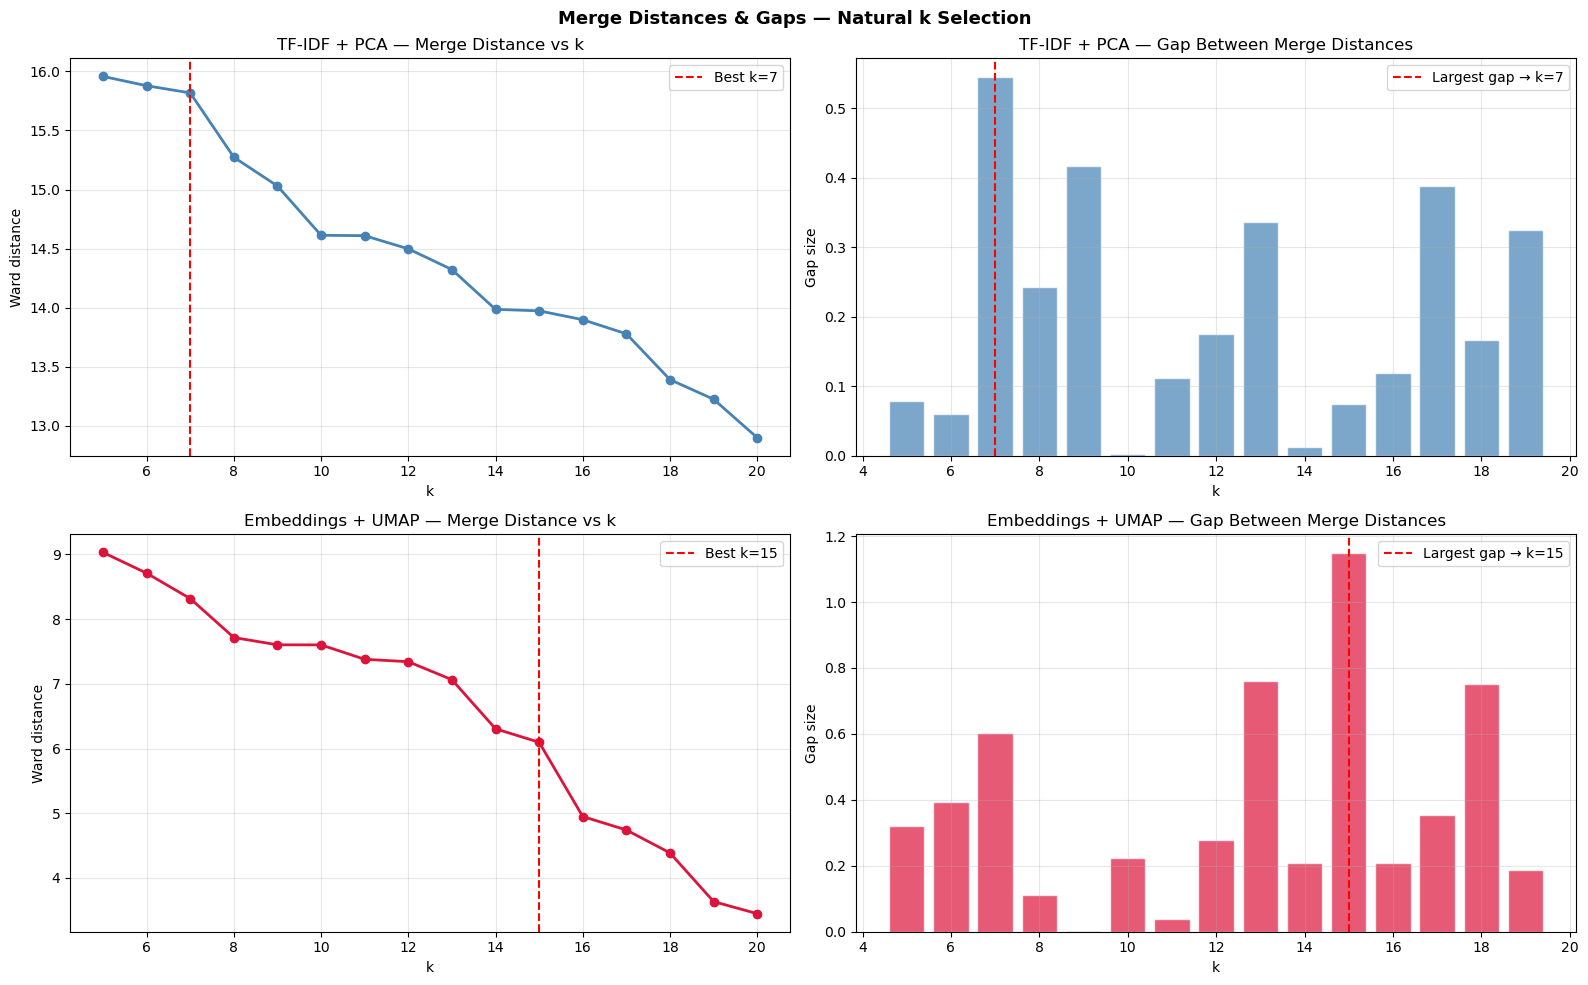

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Merge Distances & Gaps — Natural k Selection', fontsize=13, fontweight='bold')
for row, (ks, dists, gaps, thresh, k, name, color) in enumerate([
    (ks_t, dists_t, gaps_t, thresh_tfidf, k_tfidf, 'TF-IDF + PCA',     'steelblue'),
    (ks_e, dists_e, gaps_e, thresh_embed, k_embed, 'Embeddings + UMAP', 'crimson'),
]):
    axes[row, 0].plot(ks, dists, 'o-', color=color, linewidth=2)
    axes[row, 0].axvline(k, color='red', linestyle='--', label=f'Best k={k}')
    axes[row, 0].set_title(f'{name} — Merge Distance vs k')
    axes[row, 0].set_xlabel('k'); axes[row, 0].set_ylabel('Ward distance')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].bar(ks[:-1], gaps, color=color, alpha=0.7, edgecolor='white')
    axes[row, 1].axvline(k, color='red', linestyle='--', label=f'Largest gap → k={k}')
    axes[row, 1].set_title(f'{name} — Gap Between Merge Distances')
    axes[row, 1].set_xlabel('k'); axes[row, 1].set_ylabel('Gap size')
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 4.5 Apply Cut — Get Labels

In [25]:
lbl_tfidf = fcluster(Z_tfidf, t=k_tfidf, criterion='maxclust') - 1
lbl_embed = fcluster(Z_embed, t=k_embed, criterion='maxclust') - 1
k_actual_tfidf = len(np.unique(lbl_tfidf))
k_actual_embed = len(np.unique(lbl_embed))
sil_t = silhouette_score(X_tfidf_pca,  lbl_tfidf)
sil_e = silhouette_score(X_embed_umap, lbl_embed)
print(f'TF-IDF     → k={k_actual_tfidf}, Silhouette={sil_t:.4f}')
print(f'Embeddings → k={k_actual_embed}, Silhouette={sil_e:.4f}')


TF-IDF     → k=7, Silhouette=0.0949
Embeddings → k=15, Silhouette=0.6333


### 4.6 Silhouette Analysis per Cluster

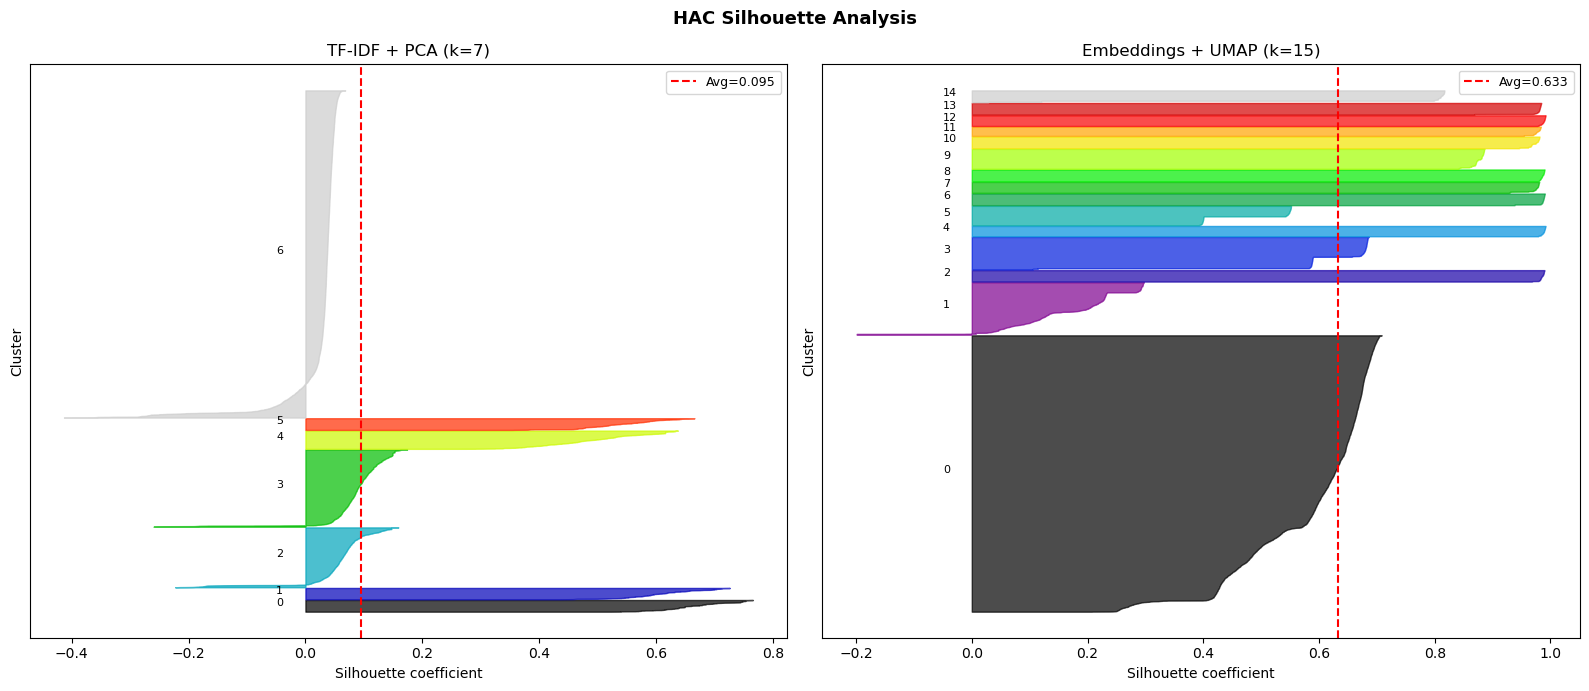

In [26]:
def plot_silhouette(X, labels, title, ax):
    k = len(np.unique(labels))
    sil_vals = silhouette_samples(X, labels)
    y_lower = 10
    colors = cm.nipy_spectral(np.linspace(0, 1, k))
    for i in range(k):
        vals = np.sort(sil_vals[labels == i])
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5*len(vals), str(i), fontsize=8)
        y_lower = y_upper + 10
    ax.axvline(sil_vals.mean(), color='red', linestyle='--', label=f'Avg={sil_vals.mean():.3f}')
    ax.set_title(title); ax.set_xlabel('Silhouette coefficient')
    ax.set_ylabel('Cluster'); ax.legend(fontsize=9); ax.set_yticks([])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_silhouette(X_tfidf_pca,  lbl_tfidf, f'TF-IDF + PCA (k={k_actual_tfidf})',     axes[0])
plot_silhouette(X_embed_umap, lbl_embed, f'Embeddings + UMAP (k={k_actual_embed})', axes[1])
plt.suptitle('HAC Silhouette Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.7 2D Cluster Visualisation

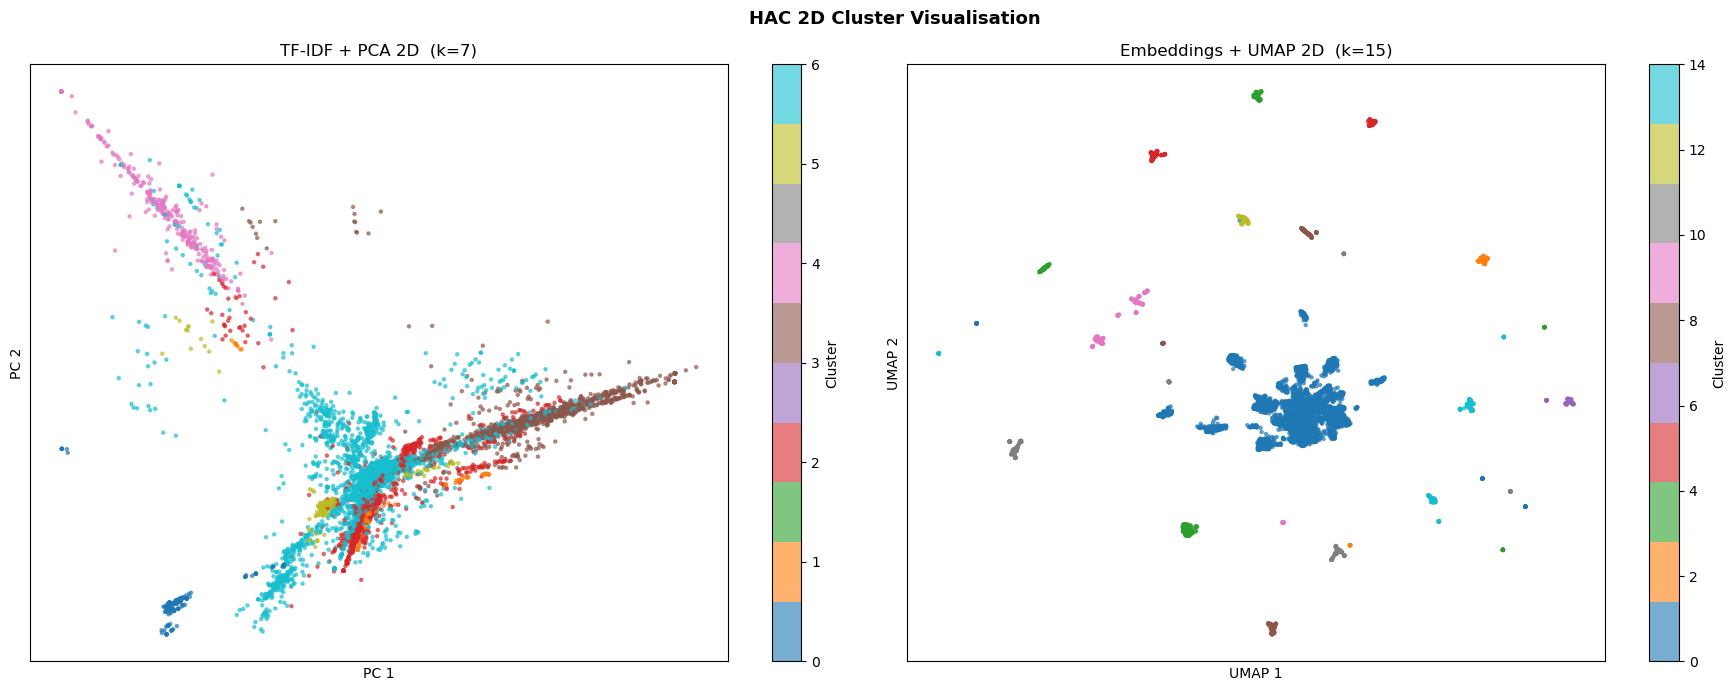

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, X_2d, labels, k, xlabel, ylabel, name in [
    (axes[0], X_tfidf_2d, lbl_tfidf, k_actual_tfidf, 'PC 1',   'PC 2',   'TF-IDF + PCA'),
    (axes[1], X_embed_2d, lbl_embed, k_actual_embed, 'UMAP 1', 'UMAP 2', 'Embeddings + UMAP'),
]:
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
    ax.set_title(f'{name} 2D  (k={k})', fontsize=12)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, label='Cluster')
plt.suptitle('HAC 2D Cluster Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.8 Cluster Size Distribution

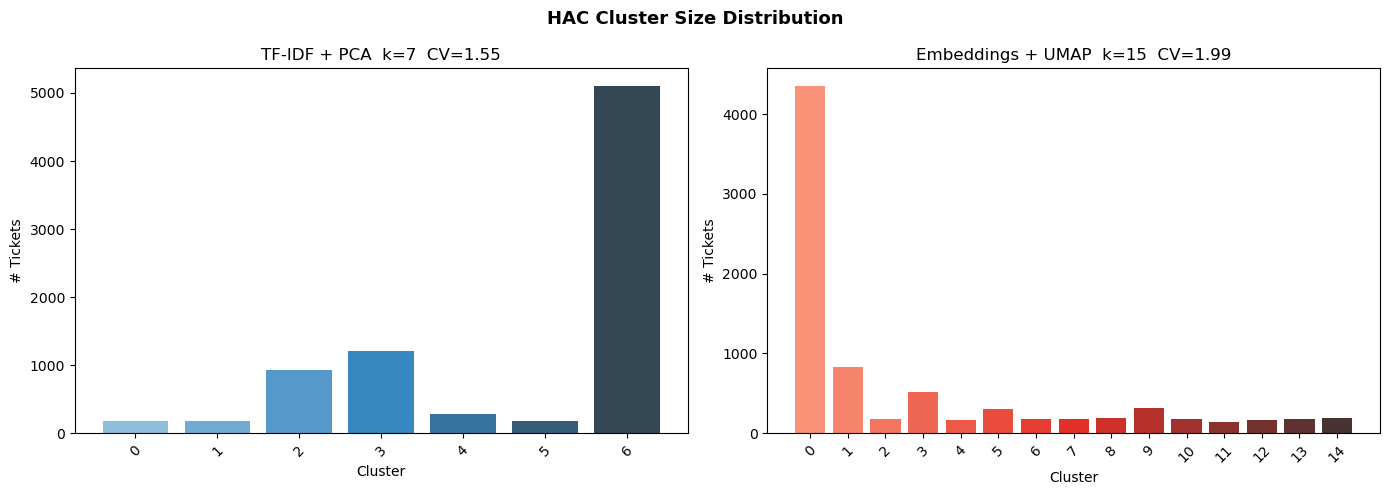

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HAC Cluster Size Distribution', fontsize=13, fontweight='bold')
for ax, labels, k, X_c, name, palette in [
    (axes[0], lbl_tfidf, k_actual_tfidf, X_tfidf_pca,  'TF-IDF + PCA',     'Blues_d'),
    (axes[1], lbl_embed, k_actual_embed, X_embed_umap, 'Embeddings + UMAP', 'Reds_d'),
]:
    sizes = pd.Series(labels).value_counts().sort_index()
    cv = sizes.std() / sizes.mean()
    ax.bar(sizes.index.astype(str), sizes.values, color=sns.color_palette(palette, k))
    ax.set_title(f'{name}  k={k}  CV={cv:.2f}')
    ax.set_xlabel('Cluster'); ax.set_ylabel('# Tickets')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

### 4.9 Top Keywords per Cluster

In [29]:
data_df['cluster_tfidf'] = lbl_tfidf
data_df['cluster_embed'] = lbl_embed

def get_top_keywords(text_series, n=8):
    words = ' '.join(text_series).split()
    words = [w for w in words if len(w) > 3 and not w.isnumeric()]
    return [w for w, _ in Counter(words).most_common(n)]

for col, name, k, in [
    ('cluster_tfidf', 'TF-IDF + PCA',     k_actual_tfidf),
    ('cluster_embed', 'Embeddings + UMAP', k_actual_embed),
]:
    print('=' * 70)
    print(f'HAC — {name}  |  k={k}')
    print('=' * 70)
    for i in range(k):
        docs = data_df[data_df[col] == i]
        kw = get_top_keywords(docs['processed_text'])
        dom = docs['Ticket Subject'].value_counts().index[0] if len(docs) > 0 else 'N/A'
        print(f'  C{i:02d} (n={len(docs):4d}, dom={dom:<30s}): {kw}')
    print()

HAC — TF-IDF + PCA  |  k=7
  C00 (n= 183, dom=Installation support          ): ['account', 'access', 'unable', 'error', 'login', 'correct', 'regain', 'keep']
  C01 (n= 178, dom=Product compatibility         ): ['network', 'connecting', 'resolve', 'wifi', 'home', 'trouble', 'detect', 'although']
  C02 (n= 935, dom=Battery life                  ): ['data', 'file', 'loss', 'deleted', 'recover', 'safe', 'security', 'concerned']
  C03 (n=1205, dom=Product compatibility         ): ['update', 'software', 'product', 'updated', 'afterward', 'firmware', 'havent', 'version']
  C04 (n= 286, dom=Product setup                 ): ['error', 'message', 'screen', 'peculiar', 'popping', 'product', 'purchase', 'purchased']
  C05 (n= 183, dom=Account access                ): ['network', 'internet', 'connection', 'troubleshoot', 'unable', 'stable', 'establish', 'disconnecting']
  C06 (n=5107, dom=Software bug                  ): ['product', 'account', 'resolve', 'reset', 'unable', 'productivity', 'troublesh

### 4.10 Word Clouds (Best k — Embeddings)

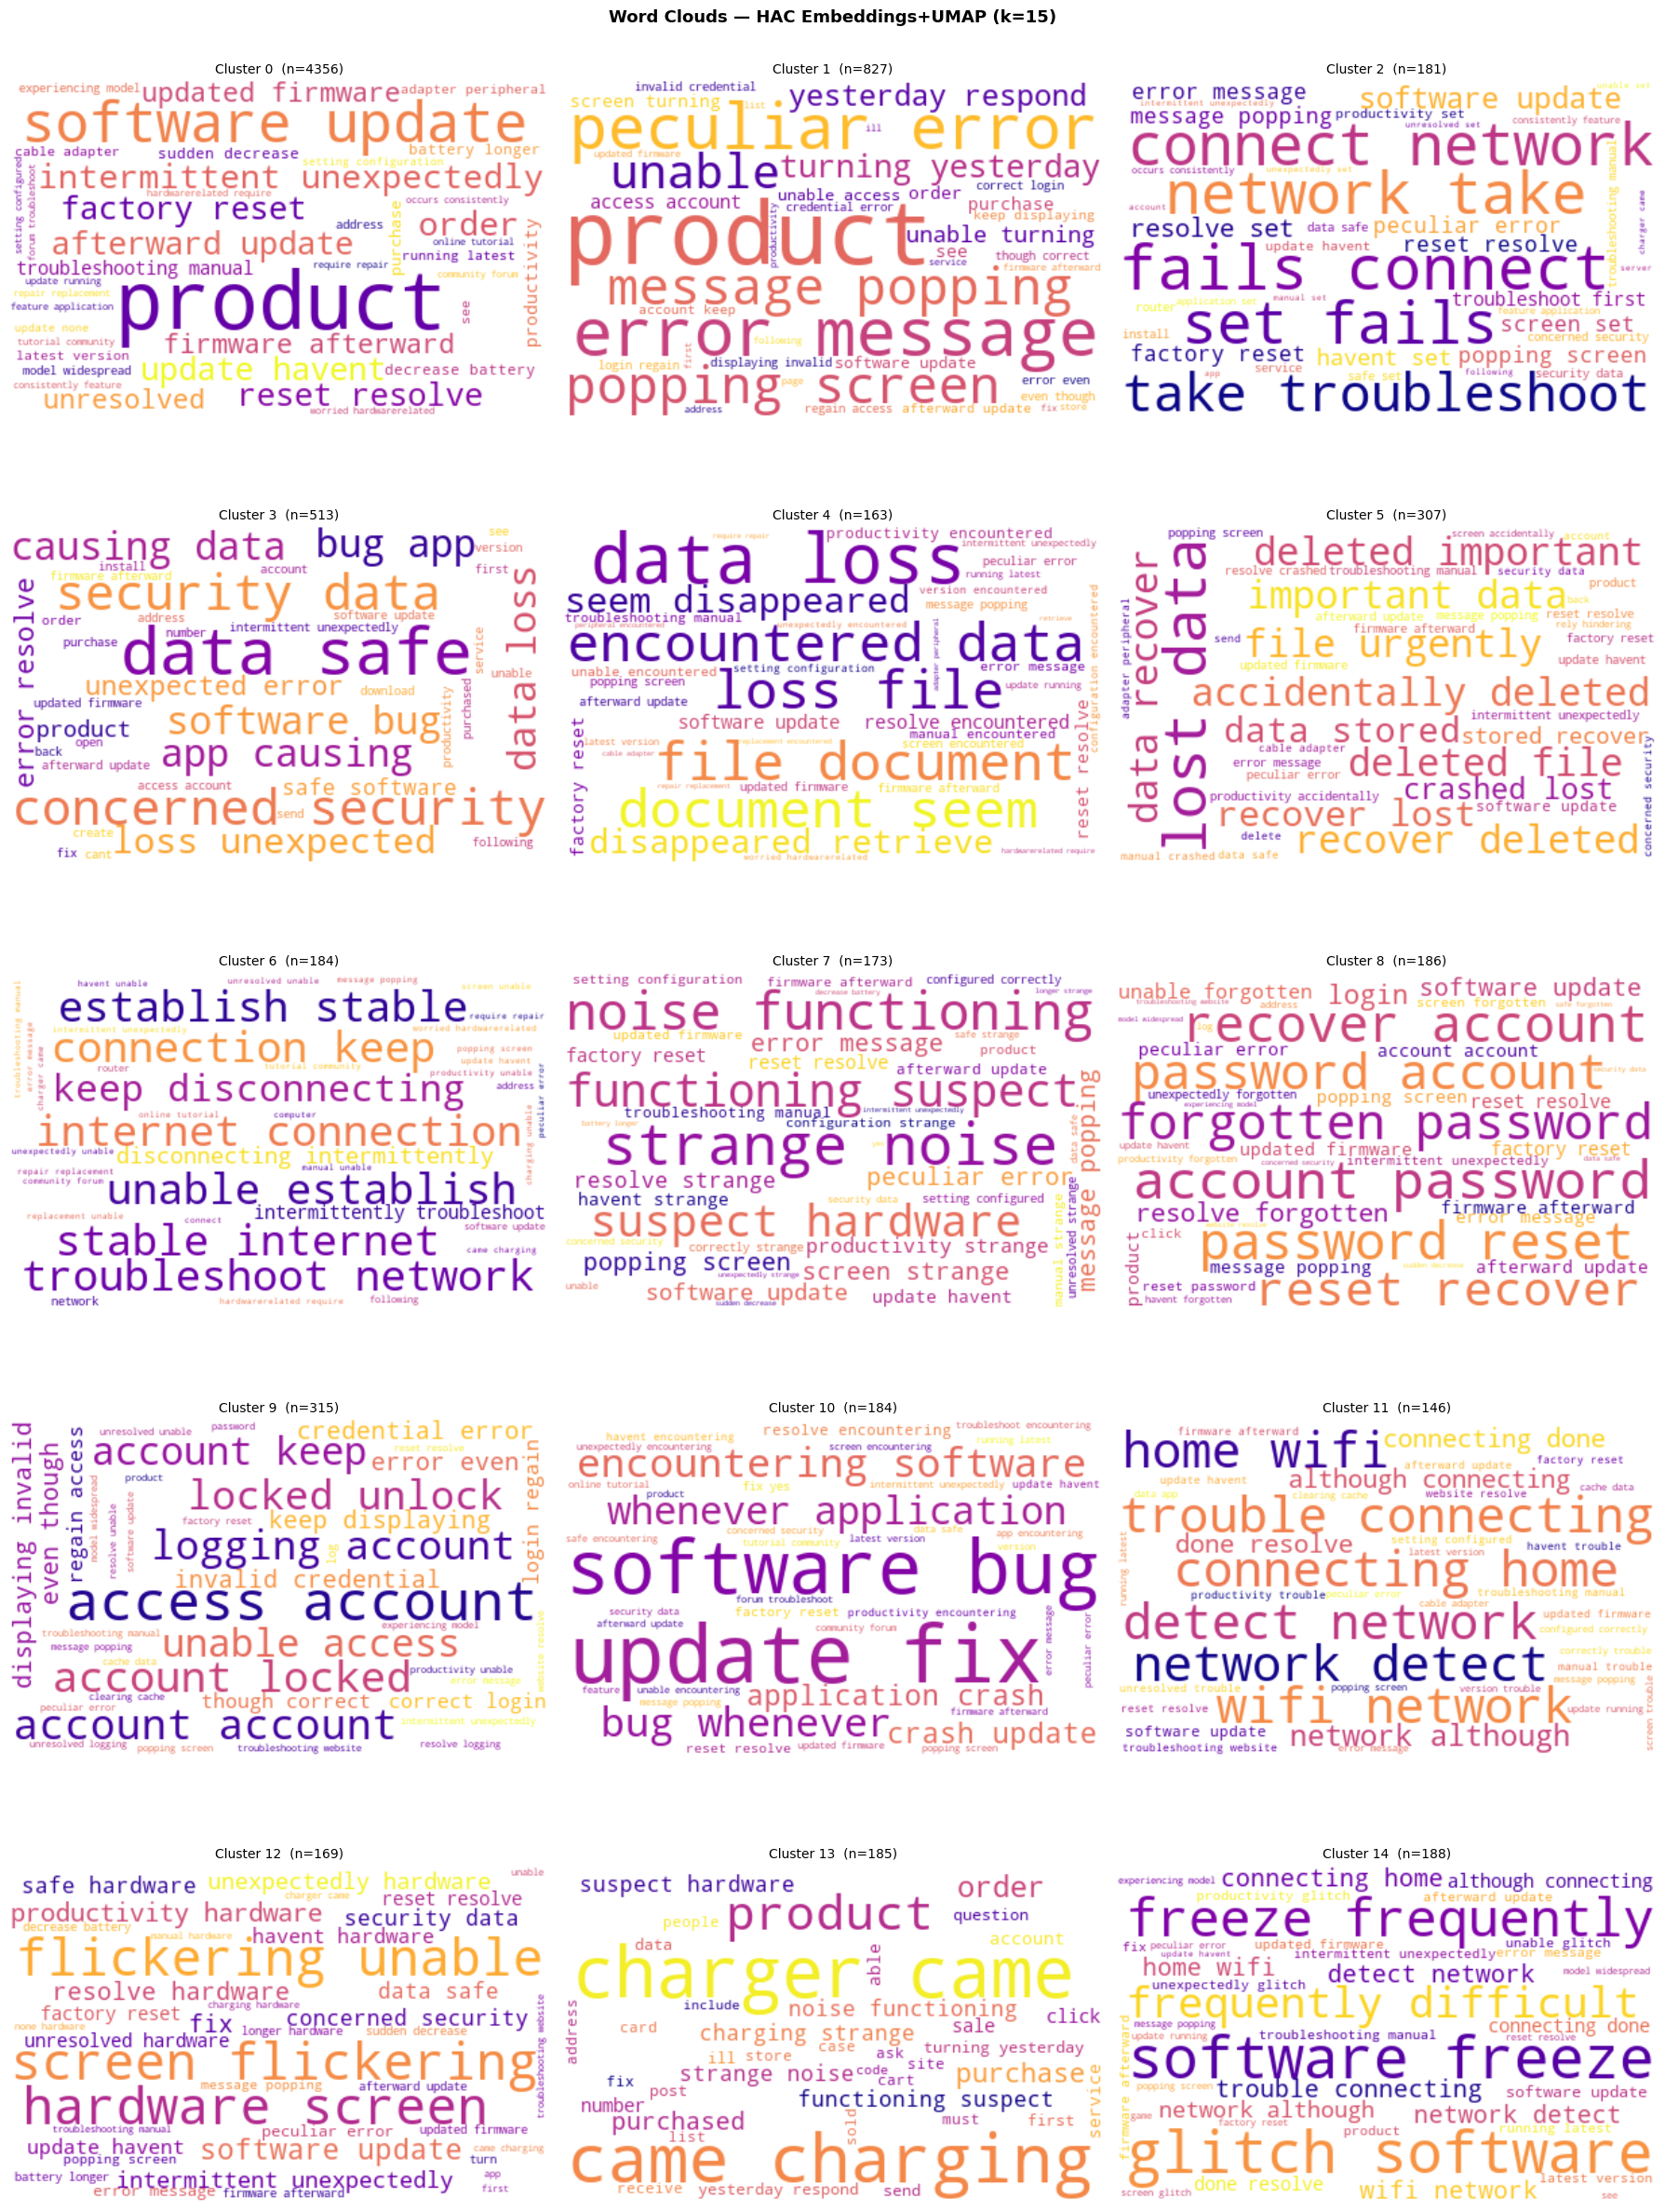

In [30]:
k = k_actual_embed
ncols = 3
nrows = math.ceil(k / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
axes = axes.flatten()
for i in range(k):
    docs = data_df[data_df['cluster_embed'] == i]['processed_text']
    text = ' '.join(docs)
    if text.strip():
        wc = WordCloud(width=400, height=250, background_color='white',
                       colormap='plasma', max_words=40).generate(text)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Cluster {i}  (n={len(docs)})', fontsize=10)
    axes[i].axis('off')
for j in range(k, len(axes)): axes[j].axis('off')
plt.suptitle(f'Word Clouds — HAC Embeddings+UMAP (k={k})', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Summary

In [31]:
print('=' * 50)
print('HAC Clustering Summary')
print('=' * 50)
for labels, X_c, k, name in [
    (lbl_tfidf, X_tfidf_pca,  k_actual_tfidf, 'TF-IDF + PCA'),
    (lbl_embed, X_embed_umap, k_actual_embed,  'Embeddings + UMAP'),
]:
    sizes = pd.Series(labels).value_counts()
    sil = silhouette_score(X_c, labels)
    cv  = sizes.std() / sizes.mean()
    print(f'\n{name}')
    print(f'  Natural k       : {k}')
    print(f'  Silhouette      : {sil:.4f}')
    print(f'  Size CV         : {cv:.3f}')
    print(f'  Largest cluster : {sizes.max()} tickets')
    print(f'  Smallest cluster: {sizes.min()} tickets')

HAC Clustering Summary

TF-IDF + PCA
  Natural k       : 7
  Silhouette      : 0.0949
  Size CV         : 1.553
  Largest cluster : 5107 tickets
  Smallest cluster: 178 tickets

Embeddings + UMAP
  Natural k       : 15
  Silhouette      : 0.6333
  Size CV         : 1.990
  Largest cluster : 4356 tickets
  Smallest cluster: 146 tickets
